# Лабораторная работа №2 – Временные ряды
**Восстановление погодных данных и прогноз температуры на неделю**

Цель работы: освоить основные приёмы работы с временными рядами: очистку и приведение данных к единому формату, исследовательский анализ, обучение и настройку моделей машинного обучения для задачи прогнозирования.


## 1. Получение доступа ко всем листам Excel-файла

В данном разделе выполняется подготовка доступа к исходным данным: подключаются необходимые библиотеки, определяется расположение файла, проверяются открытые и скрытые листы, после чего из Excel-книги извлекаются все погодные таблицы.


### 1.1. Импорт библиотек и настройки


In [1]:
from __future__ import annotations

from pathlib import Path
from difflib import get_close_matches
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from openpyxl import load_workbook

from scipy import signal
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, acf, pacf

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42
HORIZON_HOURS = 24 * 7
ANCHOR_STEP_HOURS = 24
N_TRIALS = 8
MAX_TUNING_ROWS = 35_000

DIRECT_TUNING_HORIZONS = [1, 3, 6, 12, 24, 48, 72, 96, 120, 144, 168]

np.random.seed(RANDOM_STATE)

### 1.2. Поиск входного файла

Путь к данным задан с учётом разных вариантов запуска: ноутбук сможет найти файл как рядом с лабораторной работой, так и в каталоге `data/have_fun.xlsx`, а также в проверочной среде, где файл может находиться в `/mnt/data`.


In [2]:
DATA_PATH_CANDIDATES = [
    Path("have_fun.xlsx"),
    Path("data/have_fun.xlsx"),
    Path("../data/have_fun.xlsx"),
    Path("/mnt/data/have_fun.xlsx"),
]

DATA_PATH = next((path for path in DATA_PATH_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Не найден have_fun.xlsx. Положите файл рядом с ноутбуком или в папку data/."
    )

DATA_PATH

PosixPath('have_fun.xlsx')

### 1.3. Доступ к видимым и скрытым листам Excel

`pandas.read_excel()` корректно обрабатывает стандартные таблицы, однако в данной книге часть информации размещена на скрытых листах и внутри смещённого диапазона. Поэтому на первом этапе используется `openpyxl`: он позволяет увидеть метаданные листов и последовательно просмотреть все ячейки книги.


In [3]:
WEATHER_COLUMNS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "weathercode",
    "wind_speed_10m",
    "surface_pressure",
    "ds",
    "city",
]

NUMERIC_COLUMNS = WEATHER_COLUMNS[:8]
CONTINUOUS_COLUMNS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "wind_speed_10m",
    "surface_pressure",
]
NON_NEGATIVE_COLUMNS = ["precipitation", "rain", "snowfall", "wind_speed_10m"]


def fix_mojibake(value):
    if not isinstance(value, str):
        return value
    try:
        return value.encode("latin1").decode("cp1251")
    except Exception:
        return value


workbook = load_workbook(DATA_PATH, read_only=True, data_only=True)

sheet_info = []
for ws in workbook.worksheets:
    sheet_info.append(
        {
            "sheet_name_raw": fix_mojibake(ws.title),
            "sheet_name": fix_mojibake(ws.title),
            "sheet_state": ws.sheet_state,
        }
    )

sheet_info = pd.DataFrame(sheet_info)
workbook.close()
sheet_info

,sheet_name_raw,sheet_name,sheet_state
0,Лист1,Лист1,visible
1,Лист1,Лист1,visible
2,МАИ,МАИ,visible
3,это,это,visible
4,я,я,visible
5,!,!,visible
6,Лист2_строковые_NaN_выбросы,Лист2_строковые_NaN_выбросы,hidden
7,Лист3_смешанные_типы,Лист3_смешанные_типы,hidden


### 1.4. Парсер таблиц внутри листов

В Excel-файле присутствует не только обычная таблица, где заголовки расположены в первой строке, но и блок, сдвинутый вправо: внутри листа повторно встречаются заголовки `temperature_2m ... city`, а сами наблюдения продолжаются в другом диапазоне столбцов. Функция ниже находит такие заголовки в любой части строки и извлекает все обнаруженные табличные фрагменты.


In [4]:
def parse_weather_workbook(path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    wb = load_workbook(path, read_only=True, data_only=True)
    records = []
    diagnostics = []

    for ws in wb.worksheets:
        active_table_starts: list[int] = []
        rows_scanned = 0
        rows_extracted = 0

        for excel_row, row in enumerate(ws.iter_rows(values_only=True), start=1):
            rows_scanned += 1

            # 1) Сначала извлекаем данные из уже найденных таблиц.
            for start_col in active_table_starts:
                if start_col + len(WEATHER_COLUMNS) <= len(row):
                    segment = list(row[start_col : start_col + len(WEATHER_COLUMNS)])
                    is_header = segment == WEATHER_COLUMNS
                    has_data = any(value is not None for value in segment)

                    if has_data and not is_header:
                        records.append(
                            segment
                            + [fix_mojibake(ws.title), fix_mojibake(ws.title), excel_row, start_col + 1]
                        )
                        rows_extracted += 1

            # 2) После извлечения ищем новые заголовки, включая смещённые вправо.
            for start_col, value in enumerate(row):
                if value != "temperature_2m":
                    continue
                if start_col + len(WEATHER_COLUMNS) > len(row):
                    continue
                candidate_header = list(row[start_col : start_col + len(WEATHER_COLUMNS)])
                if candidate_header == WEATHER_COLUMNS and start_col not in active_table_starts:
                    active_table_starts.append(start_col)

        print(f"Лист обработан: {fix_mojibake(ws.title)} | строк извлечено: {rows_extracted:,}")
        diagnostics.append(
            {
                "sheet_name_raw": fix_mojibake(ws.title),
                "sheet_name": fix_mojibake(ws.title),
                "sheet_state": ws.sheet_state,
                "table_start_columns": [col + 1 for col in active_table_starts],
                "rows_scanned": rows_scanned,
                "rows_extracted": rows_extracted,
            }
        )

    columns = WEATHER_COLUMNS + [
        "source_sheet_raw",
        "source_sheet",
        "excel_row",
        "excel_start_col",
    ]
    return pd.DataFrame(records, columns=columns), pd.DataFrame(diagnostics)


raw_weather, parse_diagnostics = parse_weather_workbook(DATA_PATH)

print(f"Всего извлечено строк: {len(raw_weather):,}")
display(parse_diagnostics)
raw_weather.head()

Лист обработан: Лист1 | строк извлечено: 125,124
Лист обработан: Лист1 | строк извлечено: 0
Лист обработан: МАИ | строк извлечено: 0
Лист обработан: это | строк извлечено: 0
Лист обработан: я | строк извлечено: 0
Лист обработан: ! | строк извлечено: 0
Лист обработан: Лист2_строковые_NaN_выбросы | строк извлечено: 122,828
Лист обработан: Лист3_смешанные_типы | строк извлечено: 122,736
Всего извлечено строк: 370,688


,sheet_name_raw,sheet_name,sheet_state,table_start_columns,rows_scanned,rows_extracted
0,Лист1,Лист1,visible,[1],125125,125124
1,Лист1,Лист1,visible,[],0,0
2,МАИ,МАИ,visible,[],1000,0
3,это,это,visible,[],1000,0
4,я,я,visible,[],1000,0
5,!,!,visible,[],1000,0
6,Лист2_строковые_NaN_выбросы,Лист2_строковые_NaN_выбросы,hidden,"[1, 16, 12]",125170,122828
7,Лист3_смешанные_типы,Лист3_смешанные_типы,hidden,[1],122737,122736


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city,source_sheet_raw,source_sheet,excel_row,excel_start_col
0,3.8,82.0,0.0,0.0,0.0,3.0,19.1,1010.000000,2020-01-31 02:00:00,Ãåëåíäæèê,Лист1,Лист1,2,1
1,-3.0,70.0,0.0,0.0,0.0,3.0,24.0,981.900024,2025-02-28 09:00:00,Áëàãîâåùåíñê,Лист1,Лист1,3,1
2,-1.3,86.0,0.0,0.0,0.0,2.0,8.8,1021.200012,2022-01-03 02:00:00,Ãåëåíäæèê,Лист1,Лист1,4,1
3,19.299999,49.0,0.0,0.0,0.0,0.0,22.799999,1016.200012,2020-09-17 06:00:00,Ãåëåíäæèê,Лист1,Лист1,5,1
4,9.6,89.0,0.0,0.0,0.0,0.0,8.8,1024.400024,2025-04-16 05:00:00,Ãåëåíäæèê,Лист1,Лист1,6,1


### 1.5. Первичная диагностика извлечённых данных

Проверим смешение типов, строковые обозначения пропусков и разные варианты написания городов. Такая диагностика позволяет не выполнять очистку вслепую и сразу выявить проблемы, появившиеся из-за ручного заполнения Excel-файла.


In [5]:
def collect_string_markers(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for column in columns:
        values = sorted({value for value in frame[column].dropna() if isinstance(value, str)})
        if values:
            rows.append({"column": column, "string_values": values[:20], "n_unique_strings": len(values)})
    return pd.DataFrame(rows)


raw_city_values = (
    raw_weather["city"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .map(lambda x: {"raw": x, "decoded": fix_mojibake(x)})
    .tolist()
)
raw_city_values = pd.DataFrame(raw_city_values).sort_values("decoded")

print("Варианты городов до нормализации:")
display(raw_city_values)

print("Строковые значения в числовых колонках:")
display(collect_string_markers(raw_weather, NUMERIC_COLUMNS))

Варианты городов до нормализации:


,raw,decoded
2,ÁËÀÃÎÂÅÙÅÍÑÊ,БЛАГОВЕЩЕНСК
3,Áëàãîâåùåíñ,Благовещенс
1,Áëàãîâåùåíñê,Благовещенск
4,Áëàãîâåùåíñêê,Благовещенскк
6,ÃÅËÅÍÄÆÈÊ,ГЕЛЕНДЖИК
9,Ãåëåíäæè,Геленджи
0,Ãåëåíäæèê,Геленджик
8,Ãåëåíäæèêê,Геленджикк
12,Ìîñâà,Мосва
10,Ìîñêâà,Москва


Строковые значения в числовых колонках:


,column,string_values,n_unique_strings
0,temperature_2m,"[---, ?, NA, NAN, NULL, NaN, n/a, null, æàðêî,...",12
1,precipitation,"[---, ?, NA, NAN, NULL, NaN, n/a, null, ëèâåíü...",12
2,weathercode,"[äîæäü, ïàñìóðíî, ñíåã, ñîëíå÷íî]",4
3,wind_speed_10m,"[---, ?, NA, NAN, NULL, NaN, n/a, null, âåòðåí...",14


## 2. Очистка и унификация данных

Во втором разделе данные приводятся к единому и согласованному виду: исправляются кодировки и названия городов, числовые поля очищаются от строковых элементов, выбросов и повторов, а для каждого города формируется общий почасовой временной индекс.


In [6]:
def normalize_city(value):
    if pd.isna(value):
        return np.nan

    city = fix_mojibake(str(value)).strip()
    city = city.replace("ё", "е").replace("Ё", "Е")
    city = re.sub(r"\s+", " ", city).title()

    manual_fixes = {
        "Мосва": "Москва",
        "Благовещенс": "Благовещенск",
        "Благовещенскк": "Благовещенск",
        "Геленджи": "Геленджик",
        "Геленджикк": "Геленджик",
        "Соч": "Сочи",
        "Счи": "Сочи",
        "Сычи": "Сочи",
    }
    city = manual_fixes.get(city, city)

    allowed_cities = [
        "Москва",
        "Санкт-Петербург",
        "Сочи",
        "Находка",
        "Благовещенск",
        "Геленджик",
    ]
    if city not in allowed_cities:
        match = get_close_matches(city, allowed_cities, n=1, cutoff=0.78)
        if match:
            city = match[0]

    return city


TEXT_TO_WEATHERCODE = {
    "солнечно": 0,
    "пасмурно": 3,
    "дождь": 61,
    "снег": 71,
}
TEXT_TO_PRECIPITATION = {
    "сухо": 0.0,
    "морось": 0.1,
    "ливень": 10.0,
}
MISSING_MARKERS = {"nan", "na", "n/a", "null", "?", "---", "нет данных", ""}


def coerce_weather_value(value, column: str):
    if isinstance(value, str):
        text = fix_mojibake(value).strip().lower()
        if text in MISSING_MARKERS:
            return np.nan
        if column == "weathercode":
            return TEXT_TO_WEATHERCODE.get(text, np.nan)
        if column == "precipitation":
            return TEXT_TO_PRECIPITATION.get(text, np.nan)
        return np.nan
    return value


clean_weather = raw_weather.copy()
clean_weather["city"] = clean_weather["city"].map(normalize_city)
clean_weather["source_sheet"] = clean_weather["source_sheet"].map(fix_mojibake)
clean_weather["ds"] = pd.to_datetime(clean_weather["ds"], errors="coerce")

for column in NUMERIC_COLUMNS:
    clean_weather[column] = pd.to_numeric(
        clean_weather[column].map(lambda value, col=column: coerce_weather_value(value, col)),
        errors="coerce",
    )

quality_before_bounds = pd.DataFrame(
    {
        "missing": clean_weather[WEATHER_COLUMNS].isna().sum(),
        "missing_share": clean_weather[WEATHER_COLUMNS].isna().mean().round(4),
        "dtype": clean_weather[WEATHER_COLUMNS].dtypes.astype(str),
    }
)
quality_before_bounds

,missing,missing_share,dtype
temperature_2m,4365,0.0118,float64
relative_humidity_2m,45,0.0001,float64
precipitation,3017,0.0081,float64
rain,0,0.0000,float64
snowfall,0,0.0000,float64
weathercode,0,0.0000,float64
wind_speed_10m,3089,0.0083,float64
surface_pressure,0,0.0000,float64
ds,1,0.0000,datetime64[us]
city,0,0.0000,str


### 2.1. Исправление физических ограничений и выбросов

На первом шаге исключаются явно невозможные значения. Например, скорость ветра не может быть отрицательной, влажность должна находиться в диапазоне 0–100%, а температура `+80°C` для выбранных городов больше похожа на ошибку ручного ввода. Такие значения не удаляются вместе со строками, а заменяются на `NaN`, чтобы далее восстановить их с помощью интерполяции.


In [7]:
PHYSICAL_BOUNDS = {
    "temperature_2m": (-60, 60),
    "relative_humidity_2m": (0, 100),
    "precipitation": (0, 80),
    "rain": (0, 80),
    "snowfall": (0, 80),
    "weathercode": (0, 99),
    "wind_speed_10m": (0, 70),
    "surface_pressure": (850, 1100),
}

bounds_report = []
for column, (lower, upper) in PHYSICAL_BOUNDS.items():
    mask = clean_weather[column].notna() & ~clean_weather[column].between(lower, upper)
    bounds_report.append(
        {
            "column": column,
            "values_outside_bounds": int(mask.sum()),
            "lower_bound": lower,
            "upper_bound": upper,
        }
    )
    clean_weather.loc[mask, column] = np.nan

bounds_report = pd.DataFrame(bounds_report)
bounds_report

,column,values_outside_bounds,lower_bound,upper_bound
0,temperature_2m,427,-60,60
1,relative_humidity_2m,0,0,100
2,precipitation,613,0,80
3,rain,0,0,80
4,snowfall,0,0,80
5,weathercode,0,0,99
6,wind_speed_10m,613,0,70
7,surface_pressure,232,850,1100


### 2.2. Обработка дубликатов и построение единого почасового индекса

Если для одного города и одного часа найдено несколько записей, для числовых признаков берётся медианное значение. Медиана более устойчива, чем среднее, поэтому отдельные ручные выбросы слабее искажают восстановленный временной ряд.


In [8]:
clean_weather = clean_weather.dropna(subset=["city", "ds"]).copy()

numeric_median = clean_weather.groupby(["city", "ds"], sort=True)[NUMERIC_COLUMNS].median()
raw_record_count = clean_weather.groupby(["city", "ds"], sort=True).size().rename("raw_records")
weather_base = numeric_median.join(raw_record_count).reset_index()

print(f"Строк после агрегации city+ds: {len(weather_base):,}")
print(f"Пар city+ds с дублями: {(weather_base['raw_records'] > 1).sum():,}")

display(
    weather_base.groupby("city").agg(
        start=("ds", "min"),
        end=("ds", "max"),
        rows=("ds", "size"),
        duplicated_hours=("raw_records", lambda x: int((x > 1).sum())),
    )
)

Строк после агрегации city+ds: 368,203
Пар city+ds с дублями: 2,484


,start,end,rows,duplicated_hours
city,,,,
Благовещенск,2019-01-01,2025-12-31 23:00:00,61368,1263
Геленджик,2019-01-01,2025-12-31 23:00:00,61368,1191
Москва,2019-01-01,2025-12-31 23:00:00,61364,0
Находка,2019-01-01,2025-12-31 22:00:00,61367,30
Санкт-Петербург,2019-01-01,2025-12-31 23:00:00,61368,0
Сочи,2019-01-01,2025-12-31 23:00:00,61368,0


In [9]:
def reindex_each_city_hourly(frame: pd.DataFrame) -> pd.DataFrame:
    parts = []
    for city, city_frame in frame.groupby("city", sort=True):
        full_index = pd.date_range(
            city_frame["ds"].min().floor("h"),
            city_frame["ds"].max().ceil("h"),
            freq="h",
        )
        restored = city_frame.set_index("ds").sort_index().reindex(full_index)
        restored.index.name = "ds"
        restored["city"] = city
        restored["raw_records"] = restored["raw_records"].fillna(0).astype(int)
        parts.append(restored.reset_index())
    return pd.concat(parts, ignore_index=True).sort_values(["city", "ds"]).reset_index(drop=True)


weather_hourly = reindex_each_city_hourly(weather_base)

missing_after_reindex = weather_hourly.groupby("city")[NUMERIC_COLUMNS].apply(lambda x: x.isna().sum())
print(f"Размер после восстановления почасовой сетки: {weather_hourly.shape}")
display(missing_after_reindex)

Размер после восстановления почасовой сетки: (368207, 11)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
city,,,,,,,,
Благовещенск,914,0,635,0,0,0,597,0
Геленджик,927,0,592,0,0,0,630,0
Москва,825,4,941,4,4,4,639,114
Находка,853,30,930,0,0,0,588,122
Санкт-Петербург,622,5,266,0,0,0,638,0
Сочи,610,0,238,0,0,0,589,0


### 2.3. Восстановление пропусков

Для непрерывных признаков применяется линейная интерполяция отдельно внутри каждого города. Для `weathercode` используется заполнение ближайшими соседними значениями, так как это категориальный код состояния погоды, а не непрерывная числовая величина.


In [10]:
def fill_city_series(city_frame: pd.DataFrame) -> pd.DataFrame:
    city_frame = city_frame.sort_values("ds").copy()

    for column in CONTINUOUS_COLUMNS:
        city_frame[column] = (
            city_frame[column]
            .astype(float)
            .interpolate(method="linear", limit=48, limit_direction="both")
            .ffill()
            .bfill()
        )

    city_frame["weathercode"] = (
        city_frame["weathercode"].ffill().bfill().round().astype("Int64")
    )
    return city_frame


# Применяем функцию к каждому городу и объединяем результаты
parts = []
for city in weather_hourly["city"].unique():
    city_data = weather_hourly[weather_hourly["city"] == city]
    filled_data = fill_city_series(city_data)
    parts.append(filled_data)

weather_hourly = pd.concat(parts, ignore_index=True).sort_values(["city", "ds"]).reset_index(drop=True)

final_quality = pd.DataFrame(
    {
        "missing": weather_hourly[WEATHER_COLUMNS].isna().sum(),
        "missing_share": weather_hourly[WEATHER_COLUMNS].isna().mean().round(5),
        "dtype": weather_hourly[WEATHER_COLUMNS].dtypes.astype(str),
    }
)
final_quality

,missing,missing_share,dtype
temperature_2m,0,0.0,float64
relative_humidity_2m,0,0.0,float64
precipitation,0,0.0,float64
rain,0,0.0,float64
snowfall,0,0.0,float64
weathercode,0,0.0,Int64
wind_speed_10m,0,0.0,float64
surface_pressure,0,0.0,float64
ds,0,0.0,datetime64[us]
city,0,0.0,str


In [11]:
# Контрольные проверки после очистки.
assert weather_hourly["city"].nunique() == 6
assert weather_hourly[WEATHER_COLUMNS].isna().sum().sum() == 0
assert weather_hourly.groupby("city")["ds"].apply(lambda s: s.is_monotonic_increasing).all()

cleaning_summary = weather_hourly.groupby("city").agg(
    start=("ds", "min"),
    end=("ds", "max"),
    observations=("ds", "size"),
    temp_min=("temperature_2m", "min"),
    temp_mean=("temperature_2m", "mean"),
    temp_max=("temperature_2m", "max"),
)
cleaning_summary.round(2)

,start,end,observations,temp_min,temp_mean,temp_max
city,,,,,,
Благовещенск,2019-01-01,2025-12-31 23:00:00,61368,-41.90,2.21,35.00
Геленджик,2019-01-01,2025-12-31 23:00:00,61368,-10.00,14.36,37.80
Москва,2019-01-01,2025-12-31 23:00:00,61368,-49.98,6.68,59.95
Находка,2019-01-01,2025-12-31 22:00:00,61367,-49.99,6.83,59.97
Санкт-Петербург,2019-01-01,2025-12-31 23:00:00,61368,-28.80,6.79,35.70
Сочи,2019-01-01,2025-12-31 23:00:00,61368,-11.20,15.04,35.30


## 3. Анализ временного ряда

В третьем разделе выполняется исследовательский анализ временного ряда: строятся визуализации, сезонные профили, STL-декомпозиция, проверка стационарности, ACF/PACF и спектральный анализ. Для наглядности детальный разбор проводится на дневном среднем и на отдельном выбранном городе.


In [12]:
daily_temperature = (
    weather_hourly.set_index("ds")
    .groupby("city")["temperature_2m"]
    .resample("D")
    .mean()
    .rename("temperature_2m")
    .reset_index()
)

city_pivot_daily = daily_temperature.pivot(index="ds", columns="city", values="temperature_2m")
city_pivot_daily.head()

city,Благовещенск,Геленджик,Москва,Находка,Санкт-Петербург,Сочи
ds,,,,,,
2019-01-01,-14.037500,3.989583,-4.904167,-11.370833,-1.016667,4.725000
2019-01-02,-18.391667,6.187500,-3.206250,-11.141667,0.145833,6.750000
2019-01-03,-18.758333,8.091667,-2.591667,-10.454167,-3.504167,9.964583
2019-01-04,-20.785417,7.141667,-6.421866,-7.960417,-6.679167,10.083333
2019-01-05,-19.866667,2.845833,-6.570833,-8.966667,-6.558333,5.908333


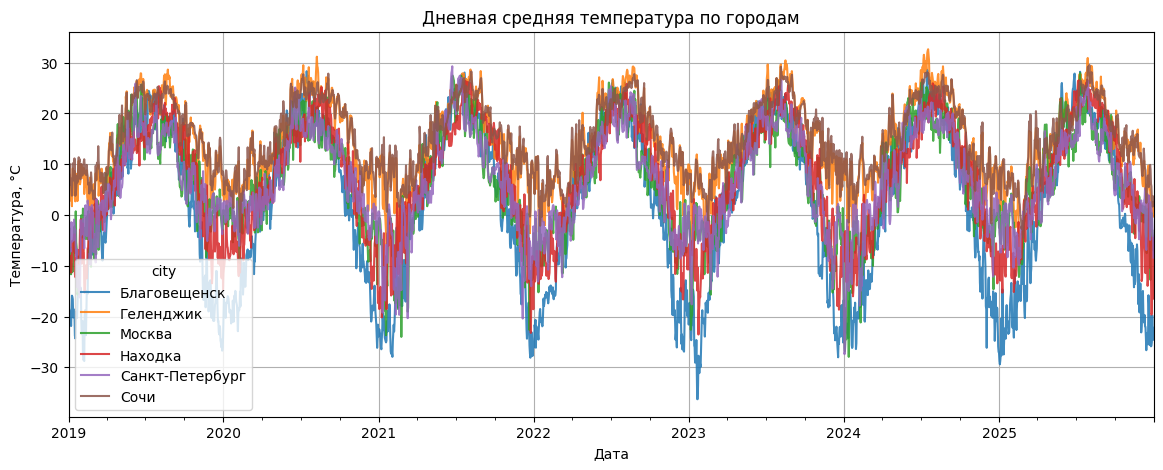

In [13]:
ax = city_pivot_daily.plot(figsize=(14, 5), alpha=0.85)
ax.set_title("Дневная средняя температура по городам")
ax.set_xlabel("Дата")
ax.set_ylabel("Температура, °C")
plt.show()

### 3.1. Визуализация и сезонный профиль

По усреднённому месячному профилю видно, что города различаются не только средним температурным уровнем, но и выраженностью сезонных колебаний. Это подтверждает необходимость использовать признак `city` и календарные характеристики.


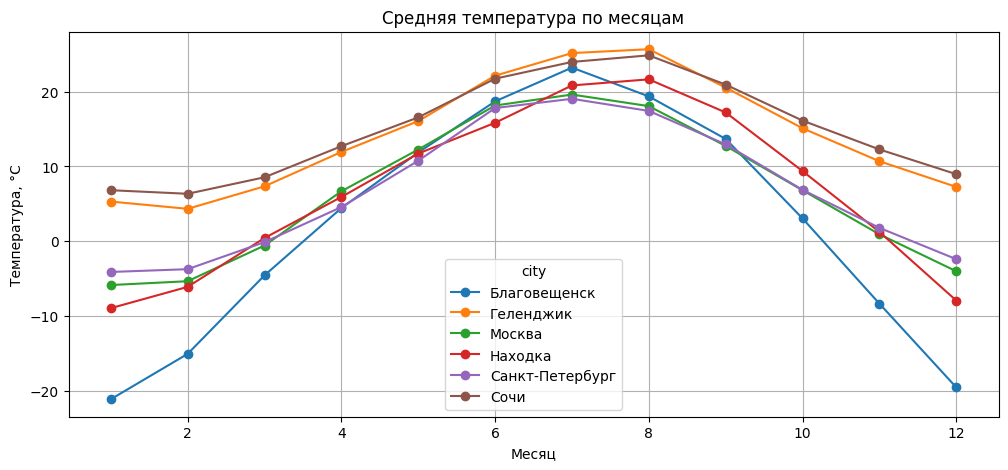

In [14]:
seasonal_profile = weather_hourly.copy()
seasonal_profile["month"] = seasonal_profile["ds"].dt.month

monthly_city_profile = (
    seasonal_profile.groupby(["city", "month"])["temperature_2m"]
    .mean()
    .reset_index()
    .pivot(index="month", columns="city", values="temperature_2m")
)

ax = monthly_city_profile.plot(marker="o", figsize=(12, 5))
ax.set_title("Средняя температура по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Температура, °C")
plt.show()

### 3.2. Декомпозиция на тренд, сезонность и остатки

Для разложения временного ряда используется STL на дневных данных. Годовая сезонность задаётся периодом 365 дней. Такой подход устойчивее классической декомпозиции в ситуациях, когда в ряду присутствуют шум и отдельные выбросы.


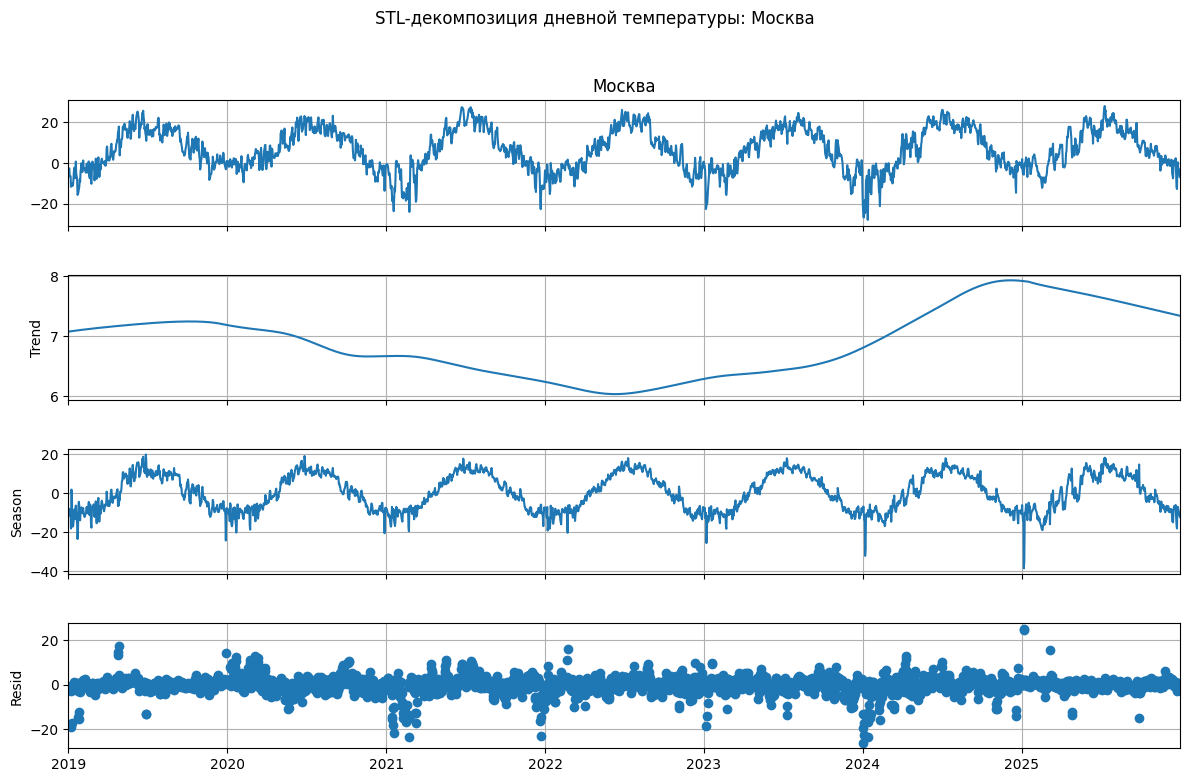

In [15]:
MAIN_CITY = "Москва"
main_daily = city_pivot_daily[MAIN_CITY].asfreq("D").interpolate()

stl = STL(main_daily, period=365, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(12, 8)
fig.suptitle(f"STL-декомпозиция дневной температуры: {MAIN_CITY}", y=1.02)
plt.show()

### 3.3. Проверка стационарности

Температурный ряд в исходных уровнях обычно не является стационарным из-за сезонной структуры. После сезонного и обычного дифференцирования ряд становится ближе к стационарному виду. Этот результат важен и для ML-моделей: лаговые признаки, скользящие статистики и календарные переменные должны учитывать сезонность.


In [16]:
def adf_report(series: pd.Series, name: str) -> dict:
    series = series.dropna()
    stat, p_value, used_lag, n_obs, critical_values, _ = adfuller(series, autolag="AIC")
    return {
        "series": name,
        "adf_statistic": stat,
        "p_value": p_value,
        "used_lag": used_lag,
        "n_obs": n_obs,
        "stationary_at_5pct": p_value < 0.05,
    }

adf_results = pd.DataFrame(
    [
        adf_report(main_daily, "level"),
        adf_report(main_daily.diff(), "diff_1"),
        adf_report(main_daily.diff(365), "seasonal_diff_365"),
        adf_report(main_daily.diff().diff(365), "diff_1_and_seasonal_365"),
    ]
)
adf_results

,series,adf_statistic,p_value,used_lag,n_obs,stationary_at_5pct
0,level,-3.156156,2.266698e-02,15,2541,True
1,diff_1,-17.719475,3.473478e-30,14,2541,True
2,seasonal_diff_365,-7.142222,3.301533e-10,19,2172,True
3,diff_1_and_seasonal_365,-14.194237,1.834281e-26,26,2164,True


### 3.4. ACF и PACF

Автокорреляционные функции используются для выбора лагов. Для погодных данных ожидаются сильные зависимости на горизонте 24 часов, а также на недельных и сезонных интервалах.


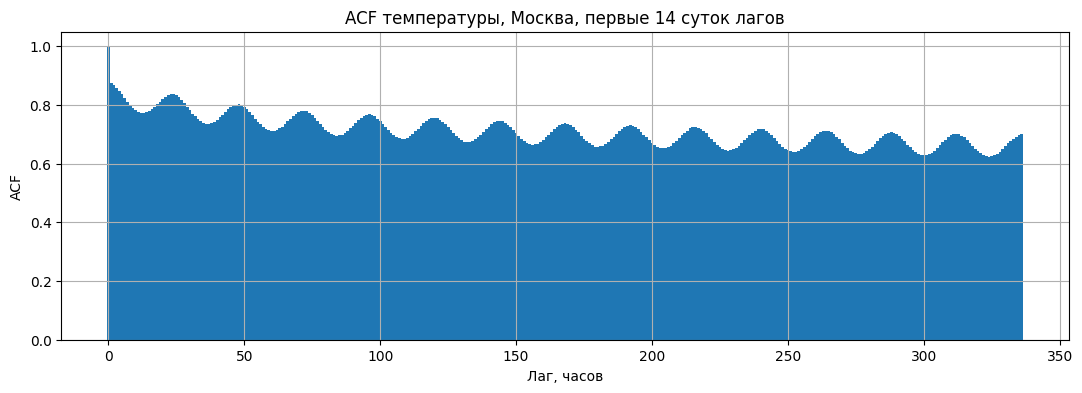

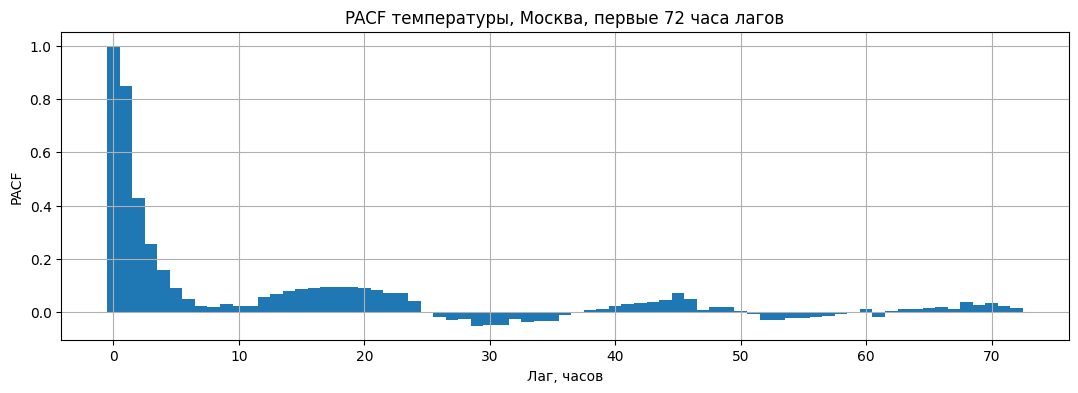

In [17]:
main_hourly = (
    weather_hourly.loc[weather_hourly["city"] == MAIN_CITY]
    .set_index("ds")["temperature_2m"]
    .asfreq("h")
)

max_lag = 24 * 14
acf_values = acf(main_hourly, nlags=max_lag, fft=True)
pacf_values = pacf(main_hourly.iloc[: 24 * 365], nlags=72, method="ywm")

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(np.arange(len(acf_values)), acf_values, width=1.0)
ax.set_title(f"ACF температуры, {MAIN_CITY}, первые 14 суток лагов")
ax.set_xlabel("Лаг, часов")
ax.set_ylabel("ACF")
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(np.arange(len(pacf_values)), pacf_values, width=1.0)
ax.set_title(f"PACF температуры, {MAIN_CITY}, первые 72 часа лагов")
ax.set_xlabel("Лаг, часов")
ax.set_ylabel("PACF")
plt.show()

### 3.5. Спектральный анализ

Периодограмма позволяет определить, какие циклы сильнее всего проявляются во временном ряду. Для температуры обычно заметны суточная и годовая сезонность, а также более короткие и среднесрочные погодные колебания.


In [18]:
def periodogram_table(series: pd.Series, sample_step_hours: float = 1.0, top_n: int = 12) -> pd.DataFrame:
    values = series.dropna().to_numpy(dtype=float)
    values = values - values.mean()
    frequencies, power = signal.periodogram(values, fs=1 / sample_step_hours, scaling="spectrum")

    table = pd.DataFrame({"frequency": frequencies, "power": power})
    table = table.loc[table["frequency"] > 0].copy()
    table["period_hours"] = 1 / table["frequency"]
    return table.sort_values("power", ascending=False).head(top_n)

spectrum_top = periodogram_table(main_hourly, sample_step_hours=1, top_n=15)
spectrum_top

,frequency,power,period_hours
7,0.000114,85.147859,8766.857143
2557,0.041667,3.564139,24.000000
2550,0.041553,0.582257,24.065882
2564,0.041781,0.518597,23.934477
8,0.000130,0.482726,7671.000000
1,0.000016,0.471565,61368.000000
10,0.000163,0.459475,6136.800000
11,0.000179,0.406824,5578.909091
68,0.001108,0.318980,902.470588
62,0.001010,0.315420,989.806452


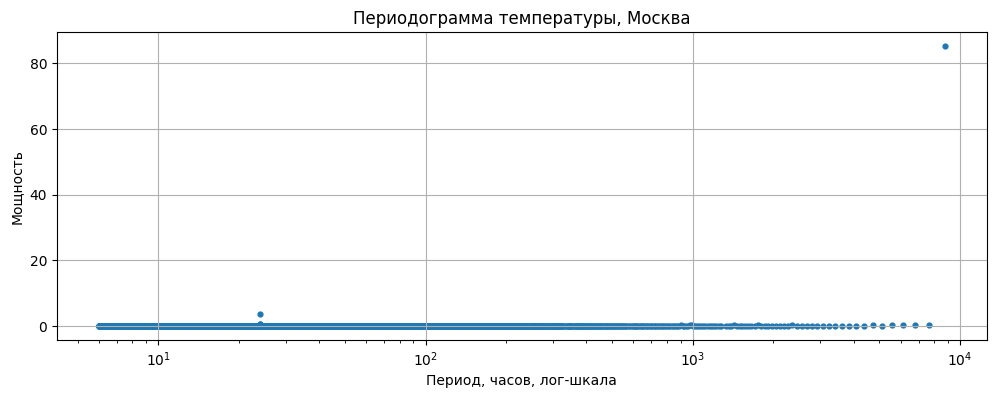

In [19]:
spectrum = periodogram_table(main_hourly, sample_step_hours=1, top_n=5000)
spectrum_for_plot = spectrum.loc[spectrum["period_hours"].between(6, 24 * 400)].copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(spectrum_for_plot["period_hours"], spectrum_for_plot["power"], s=12)
ax.set_xscale("log")
ax.set_title(f"Периодограмма температуры, {MAIN_CITY}")
ax.set_xlabel("Период, часов, лог-шкала")
ax.set_ylabel("Мощность")
plt.show()

## 4. Извлечение признаков для прогнозирования

В четвёртом разделе подготавливаются признаки для моделей машинного обучения. Лаги и скользящие статистики рассчитываются только по прошлым значениям с применением `shift(1)`, поэтому будущая температура не попадает в набор признаков.


In [20]:
def add_calendar_features(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame["hour"] = frame["ds"].dt.hour
    frame["dayofweek"] = frame["ds"].dt.dayofweek
    frame["dayofyear"] = frame["ds"].dt.dayofyear
    frame["month"] = frame["ds"].dt.month
    frame["year"] = frame["ds"].dt.year

    frame["hour_sin"] = np.sin(2 * np.pi * frame["hour"] / 24)
    frame["hour_cos"] = np.cos(2 * np.pi * frame["hour"] / 24)
    frame["dow_sin"] = np.sin(2 * np.pi * frame["dayofweek"] / 7)
    frame["dow_cos"] = np.cos(2 * np.pi * frame["dayofweek"] / 7)
    frame["doy_sin"] = np.sin(2 * np.pi * frame["dayofyear"] / 365.25)
    frame["doy_cos"] = np.cos(2 * np.pi * frame["dayofyear"] / 365.25)
    return frame


def add_lag_and_rolling_features(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.sort_values(["city", "ds"]).copy()
    grouped = frame.groupby("city", group_keys=False)

    lag_hours = [1, 2, 3, 6, 12, 24, 48, 72, 168]
    for lag in lag_hours:
        frame[f"temp_lag_{lag}h"] = grouped["temperature_2m"].shift(lag)

    rolling_windows = [6, 24, 72, 168]
    shifted_temp = grouped["temperature_2m"].shift(1)
    for window in rolling_windows:
        frame[f"temp_roll_mean_{window}h"] = shifted_temp.groupby(frame["city"]).rolling(window, min_periods=max(3, window // 4)).mean().reset_index(level=0, drop=True)
        frame[f"temp_roll_std_{window}h"] = shifted_temp.groupby(frame["city"]).rolling(window, min_periods=max(3, window // 4)).std().reset_index(level=0, drop=True)
        frame[f"temp_roll_min_{window}h"] = shifted_temp.groupby(frame["city"]).rolling(window, min_periods=max(3, window // 4)).min().reset_index(level=0, drop=True)
        frame[f"temp_roll_max_{window}h"] = shifted_temp.groupby(frame["city"]).rolling(window, min_periods=max(3, window // 4)).max().reset_index(level=0, drop=True)

    # Дополнительные погодные признаки берём только с лагом, чтобы не использовать будущее.
    for column in ["relative_humidity_2m", "wind_speed_10m", "surface_pressure", "precipitation"]:
        frame[f"{column}_lag_1h"] = grouped[column].shift(1)
        frame[f"{column}_lag_24h"] = grouped[column].shift(24)

    return frame


feature_frame = weather_hourly.pipe(add_calendar_features).pipe(add_lag_and_rolling_features)
feature_frame["target_1h"] = feature_frame.groupby("city")["temperature_2m"].shift(-1)

feature_columns = [
    column
    for column in feature_frame.columns
    if column not in [
        "ds",
        "temperature_2m",
        "target_1h",
        "raw_records",
        "weathercode",
        "relative_humidity_2m",
        "precipitation",
        "rain",
        "snowfall",
        "wind_speed_10m",
        "surface_pressure",
    ]
]

model_frame_1h = feature_frame.dropna(subset=feature_columns + ["target_1h"]).reset_index(drop=True)
print(f"Строк для one-step модели: {len(model_frame_1h):,}")
print(f"Количество признаков: {len(feature_columns)}")
feature_columns[:20]

Строк для one-step модели: 367,193
Количество признаков: 45


['city',
 'hour',
 'dayofweek',
 'dayofyear',
 'month',
 'year',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'doy_sin',
 'doy_cos',
 'temp_lag_1h',
 'temp_lag_2h',
 'temp_lag_3h',
 'temp_lag_6h',
 'temp_lag_12h',
 'temp_lag_24h',
 'temp_lag_48h',
 'temp_lag_72h']

### 4.1. Хронологическое разделение на train, validation и test

Разделение выполняется по времени, а не случайным образом. Для временных рядов это принципиально: качество модели должно проверяться на будущем участке, который не участвовал в обучении.


In [21]:
train_end = pd.Timestamp("2024-01-01")
val_end = pd.Timestamp("2025-01-01")

def split_by_time(frame: pd.DataFrame) -> pd.Series:
    return np.select(
        [frame["ds"] < train_end, frame["ds"] < val_end],
        ["train", "val"],
        default="test",
    )

model_frame_1h["split"] = split_by_time(model_frame_1h)

split_summary = model_frame_1h.groupby("split").agg(
    start=("ds", "min"),
    end=("ds", "max"),
    rows=("ds", "size"),
)
split_summary

,start,end,rows
split,,,
test,2025-01-01,2025-12-31 22:00:00,52553
train,2019-01-08,2023-12-31 23:00:00,261936
val,2024-01-01,2024-12-31 23:00:00,52704


### 4.2. Метрики для последующего сравнения моделей

Функции метрик задаются заранее, чтобы далее дерево решений, случайный лес и бустинг оценивались по одинаковым правилам.

- `MAE` — средняя абсолютная ошибка, выраженная в градусах;
- `WAPE` — относительная ошибка, нормированная на масштаб фактических наблюдений;
- `MAPE` — процентная ошибка с защитой от деления на значения, близкие к нулю;
- `directional_accuracy` — доля случаев, когда модель верно определяет направление изменения температуры;
- `directional_r2` — R² для изменений температуры, то есть показатель качества прогноза динамики.


In [22]:
def safe_mape(y_true, y_pred, eps: float = 1.0) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denominator)) * 100)


def wape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + eps) * 100)


def directional_accuracy(y_true, y_pred, baseline) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    baseline = np.asarray(baseline, dtype=float)
    return float(np.mean(np.sign(y_true - baseline) == np.sign(y_pred - baseline)))


def directional_r2(y_true, y_pred, baseline) -> float:
    y_true_delta = np.asarray(y_true, dtype=float) - np.asarray(baseline, dtype=float)
    y_pred_delta = np.asarray(y_pred, dtype=float) - np.asarray(baseline, dtype=float)
    if np.var(y_true_delta) < 1e-12:
        return np.nan
    return float(r2_score(y_true_delta, y_pred_delta))


def regression_metrics(y_true, y_pred, baseline=None) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if baseline is None:
        baseline = np.roll(y_true, 1)
        baseline[0] = y_true[0]

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "WAPE_%": wape(y_true, y_pred),
        "MAPE_%": safe_mape(y_true, y_pred),
        "directional_accuracy": directional_accuracy(y_true, y_pred, baseline),
        "directional_R2": directional_r2(y_true, y_pred, baseline),
    }

## 5. Построение моделей, Optuna и стратегии многошагового прогноза

В пятом разделе обучаются дерево решений, случайный лес и бустинг. Для настройки гиперпараметров применяется Optuna, а при отсутствии этой библиотеки предусмотрен безопасный переход к `ParameterSampler`, чтобы ноутбук оставался воспроизводимым в разных средах.


In [23]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except Exception:
    optuna = None
    OPTUNA_AVAILABLE = False

OPTUNA_AVAILABLE

True

In [24]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    optuna = None
    OPTUNA_AVAILABLE = False

OPTUNA_AVAILABLE

True

In [25]:
def limit_rows_for_tuning(X: pd.DataFrame, y: pd.Series | np.ndarray, max_rows: int = MAX_TUNING_ROWS):
    if len(X) <= max_rows:
        return X, y
    rng = np.random.default_rng(RANDOM_STATE)
    indices = np.sort(rng.choice(len(X), size=max_rows, replace=False))
    return X.iloc[indices], y[indices] if isinstance(y, np.ndarray) else y.iloc[indices]


def sklearn_param_space(model_name: str) -> dict:
    if model_name == "decision_tree":
        return {
            "max_depth": [None, 5, 10, 15],
            "min_samples_leaf": [1, 2, 4, 8],
            "min_samples_split": [2, 5, 10, 20],
        }
    if model_name == "random_forest":
        return {
            "n_estimators": [50, 100, 150],
            "max_depth": [None, 8, 15],
            "min_samples_leaf": [1, 2, 4],
            "min_samples_split": [2, 5, 10],
            "max_features": ["sqrt", "log2"],
        }
    if model_name == "hist_gradient_boosting":
        return {
            "learning_rate": [0.01, 0.05, 0.1],
            "max_iter": [100, 200, 400],
            "max_depth": [3, 5, 8],
            "min_samples_leaf": [20, 40, 80],
        }
    raise ValueError(f"Unknown model name: {model_name}")


def optuna_params(trial, model_name: str) -> dict:
    if model_name == "decision_tree":
        return {
            "max_depth": trial.suggest_categorical("max_depth", [None, 5, 10, 15]),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        }
    if model_name == "random_forest":
        return {
            "n_estimators": trial.suggest_categorical("n_estimators", [50, 100, 150]),
            "max_depth": trial.suggest_categorical("max_depth", [None, 8, 15]),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        }
    if model_name == "hist_gradient_boosting":
        return {
            "learning_rate": trial.suggest_categorical("learning_rate", [0.01, 0.05, 0.1]),
            "max_iter": trial.suggest_categorical("max_iter", [100, 200, 400]),
            "max_depth": trial.suggest_categorical("max_depth", [3, 5, 8]),
            "min_samples_leaf": trial.suggest_categorical("min_samples_leaf", [20, 40, 80]),
        }
    raise ValueError(f"Unknown model name: {model_name}")


def build_model(model_name: str, params: dict, feature_columns: list[str]) -> Pipeline:
    categorical_columns = [col for col in feature_columns if col == "city"]
    numeric_columns = [col for col in feature_columns if col not in categorical_columns]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ],
        remainder="passthrough",
    )

    if model_name == "decision_tree":
        estimator = DecisionTreeRegressor(random_state=RANDOM_STATE, **params)
    elif model_name == "random_forest":
        estimator = RandomForestRegressor(random_state=RANDOM_STATE, **params)
    elif model_name == "hist_gradient_boosting":
        estimator = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    return Pipeline([("preprocessor", preprocessor), ("model", estimator)])


def tune_model(
    model_name: str,
    X_train: pd.DataFrame,
    y_train,
    X_val: pd.DataFrame,
    y_val,
    feature_columns: list[str],
    n_trials: int = N_TRIALS,
) -> tuple[Pipeline, pd.DataFrame]:
    X_train_small, y_train_small = limit_rows_for_tuning(X_train, y_train)

    trials = []

    def evaluate(params: dict, trial_number: int):
        model = build_model(model_name, params, feature_columns)
        model.fit(X_train_small[feature_columns], y_train_small)
        pred = model.predict(X_val[feature_columns])
        score = mean_absolute_error(y_val, pred)
        trials.append({"trial": trial_number, "model": model_name, "MAE_val": score, "params": params})
        return score

    if OPTUNA_AVAILABLE:
        def objective(trial):
            return evaluate(optuna_params(trial, model_name), trial.number)

        study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        best_params = study.best_params
    else:
        sampler = ParameterSampler(
            sklearn_param_space(model_name),
            n_iter=n_trials,
            random_state=RANDOM_STATE,
        )
        best_score = np.inf
        best_params = None
        for trial_number, params in enumerate(sampler):
            score = evaluate(params, trial_number)
            if score < best_score:
                best_score = score
                best_params = params

    best_model = build_model(model_name, best_params, feature_columns)
    best_model.fit(X_train[feature_columns], y_train)
    return best_model, pd.DataFrame(trials).sort_values("MAE_val")


### 5.1. Recursive-стратегия

Recursive-подход обучает одну модель для прогноза следующего часа, после чего последовательно применяет её 168 раз. Преимущество такого варианта — простота и получение всего горизонта с помощью одной модели. Недостаток заключается в том, что ошибка может постепенно накапливаться на последующих шагах.


In [26]:
train_1h = model_frame_1h[model_frame_1h["split"] == "train"].copy()
val_1h = model_frame_1h[model_frame_1h["split"] == "val"].copy()
test_1h = model_frame_1h[model_frame_1h["split"] == "test"].copy()

X_train_1h = train_1h[feature_columns]
y_train_1h = train_1h["target_1h"]
X_val_1h = val_1h[feature_columns]
y_val_1h = val_1h["target_1h"]

recursive_models = {}
recursive_tuning_logs = []

for model_name in ["decision_tree", "random_forest", "hist_gradient_boosting"]:
    model, log = tune_model(model_name, X_train_1h, y_train_1h, X_val_1h, y_val_1h, feature_columns)
    recursive_models[model_name] = model
    recursive_tuning_logs.append(log)

recursive_tuning_results = pd.concat(recursive_tuning_logs, ignore_index=True)
recursive_tuning_results.groupby("model").head(3)

,trial,model,MAE_val,params
0,3,decision_tree,1.220034,"{'max_depth': 10, 'min_samples_leaf': 3, 'min_..."
1,5,decision_tree,1.229238,"{'max_depth': 15, 'min_samples_leaf': 8, 'min_..."
2,6,decision_tree,1.252994,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
8,1,random_forest,1.049732,"{'n_estimators': 100, 'max_depth': None, 'min_..."
9,4,random_forest,1.049732,"{'n_estimators': 100, 'max_depth': None, 'min_..."
10,7,random_forest,1.073204,"{'n_estimators': 50, 'max_depth': None, 'min_s..."
16,7,hist_gradient_boosting,1.003151,"{'learning_rate': 0.1, 'max_iter': 200, 'max_d..."
17,6,hist_gradient_boosting,1.004431,"{'learning_rate': 0.05, 'max_iter': 200, 'max_..."
18,4,hist_gradient_boosting,1.006919,"{'learning_rate': 0.1, 'max_iter': 200, 'max_d..."


In [27]:
recursive_validation_summary = []
for model_name, model in recursive_models.items():
    val_pred = model.predict(X_val_1h[feature_columns])
    metrics = regression_metrics(y_val_1h, val_pred, baseline=val_1h["temperature_2m"])
    recursive_validation_summary.append({"strategy": "recursive_1h", "model": model_name, **metrics})

recursive_validation_summary = pd.DataFrame(recursive_validation_summary).sort_values("MAE")
recursive_validation_summary

,strategy,model,MAE,WAPE_%,MAPE_%,directional_accuracy,directional_R2
2,recursive_1h,hist_gradient_boosting,0.915239,7.006575,13.527137,0.610314,0.430637
1,recursive_1h,random_forest,0.939168,7.189762,14.179091,0.594926,0.425439
0,recursive_1h,decision_tree,1.139185,8.720977,17.229932,0.542748,0.273920


### 5.2. Функция рекурсивного прогноза

Функция ниже формирует недельный прогноз от заданных якорных дат. На каждом следующем часе она обновляет историю температуры, при этом реальные будущие значения в расчётах не используются.


In [28]:
LAG_HOURS = [1, 2, 3, 6, 12, 24, 48, 72, 168]
ROLLING_WINDOWS = [6, 24, 72, 168]


def calendar_features_for_timestamp(ts: pd.Timestamp) -> dict:
    hour = ts.hour
    dayofweek = ts.dayofweek
    dayofyear = ts.dayofyear
    return {
        "hour": hour,
        "dayofweek": dayofweek,
        "dayofyear": dayofyear,
        "month": ts.month,
        "year": ts.year,
        "hour_sin": np.sin(2 * np.pi * hour / 24),
        "hour_cos": np.cos(2 * np.pi * hour / 24),
        "dow_sin": np.sin(2 * np.pi * dayofweek / 7),
        "dow_cos": np.cos(2 * np.pi * dayofweek / 7),
        "doy_sin": np.sin(2 * np.pi * dayofyear / 365.25),
        "doy_cos": np.cos(2 * np.pi * dayofyear / 365.25),
    }


def make_recursive_feature_row(city: str, current_ts: pd.Timestamp, history: pd.Series, last_weather_row: pd.Series) -> dict:
    row = {"city": city}
    row.update(calendar_features_for_timestamp(current_ts))

    for lag in LAG_HOURS:
        row[f"temp_lag_{lag}h"] = history.iloc[-lag] if len(history) >= lag else np.nan

    shifted_history = history.copy()
    for window in ROLLING_WINDOWS:
        tail = shifted_history.iloc[-window:]
        row[f"temp_roll_mean_{window}h"] = tail.mean()
        row[f"temp_roll_std_{window}h"] = tail.std(ddof=1) if len(tail) > 1 else 0.0
        row[f"temp_roll_min_{window}h"] = tail.min()
        row[f"temp_roll_max_{window}h"] = tail.max()

    for column in ["relative_humidity_2m", "wind_speed_10m", "surface_pressure", "precipitation"]:
        row[f"{column}_lag_1h"] = last_weather_row[column]
        row[f"{column}_lag_24h"] = last_weather_row[column]

    return row


def recursive_forecast_for_anchor(model: Pipeline, city_frame: pd.DataFrame, anchor_ts: pd.Timestamp, horizon: int = HORIZON_HOURS) -> pd.DataFrame:
    city_frame = city_frame.sort_values("ds").set_index("ds")
    history = city_frame.loc[:anchor_ts, "temperature_2m"].copy()
    last_weather_row = city_frame.loc[anchor_ts]

    predictions = []
    for step in range(1, horizon + 1):
        feature_ts = anchor_ts + pd.Timedelta(hours=step - 1)
        target_ts = anchor_ts + pd.Timedelta(hours=step)

        row = make_recursive_feature_row(last_weather_row["city"], feature_ts, history, last_weather_row)
        row_frame = pd.DataFrame([row])[feature_columns]
        prediction = float(model.predict(row_frame)[0])

        actual = city_frame.loc[target_ts, "temperature_2m"] if target_ts in city_frame.index else np.nan
        predictions.append(
            {
                "city": last_weather_row["city"],
                "anchor_ds": anchor_ts,
                "target_ds": target_ts,
                "horizon": step,
                "y_true": actual,
                "y_pred": prediction,
                "baseline": history.iloc[-1],
            }
        )
        history.loc[target_ts] = prediction

    return pd.DataFrame(predictions)

### 5.3. Direct-стратегия

Direct-подход создаёт отдельные целевые переменные для горизонтов `t+1`, `t+2`, ..., `t+168`. Для настройки гиперпараметров используются контрольные горизонты, чтобы сократить время выполнения ноутбука. При необходимости этот набор можно заменить на `range(1, HORIZON_HOURS + 1)`.


In [29]:
def make_anchor_frame(frame: pd.DataFrame, horizons: list[int], anchor_step_hours: int = ANCHOR_STEP_HOURS) -> pd.DataFrame:
    anchor_frame = frame.copy()
    anchor_frame = anchor_frame[anchor_frame["ds"].dt.hour % anchor_step_hours == 0].copy()

    for horizon in horizons:
        anchor_frame[f"target_h{horizon}"] = frame.groupby("city")["temperature_2m"].shift(-horizon).loc[anchor_frame.index]

    target_columns = [f"target_h{h}" for h in horizons]
    anchor_frame = anchor_frame.dropna(subset=feature_columns + target_columns).reset_index(drop=True)
    anchor_frame["split"] = split_by_time(anchor_frame)
    return anchor_frame


direct_anchor_frame = make_anchor_frame(feature_frame, DIRECT_TUNING_HORIZONS)
direct_target_columns = [f"target_h{h}" for h in DIRECT_TUNING_HORIZONS]

print(f"Строк для direct-стратегии: {len(direct_anchor_frame):,}")
direct_anchor_frame.groupby("split").agg(start=("ds", "min"), end=("ds", "max"), rows=("ds", "size"))

Строк для direct-стратегии: 15,258


,start,end,rows
split,,,
test,2025-01-01,2025-12-24,2148
train,2019-01-08,2023-12-31,10914
val,2024-01-01,2024-12-31,2196


In [30]:
def train_direct_models_by_horizon(
    model_name: str,
    params: dict,
    train_frame: pd.DataFrame,
    target_columns: list[str],
) -> dict[str, Pipeline]:
    # Обучает независимую модель для каждого горизонта direct-стратегии.
    models = {}
    for target_column in target_columns:
        model = build_model(model_name, params, feature_columns)
        model.fit(train_frame[feature_columns], train_frame[target_column])
        models[target_column] = model
    return models


def predict_direct_models(models: dict[str, Pipeline], frame: pd.DataFrame, target_columns: list[str]) -> np.ndarray:
    predictions = []
    for target_column in target_columns:
        predictions.append(models[target_column].predict(frame[feature_columns]))
    return np.vstack(predictions).T


def tune_direct_strategy(model_name: str, train_frame: pd.DataFrame, val_frame: pd.DataFrame, target_columns: list[str]) -> tuple[dict[str, Pipeline], pd.DataFrame]:
    trials = []
    X_train_small, _ = limit_rows_for_tuning(train_frame[feature_columns], train_frame[target_columns].to_numpy())
    train_small = train_frame.loc[X_train_small.index].copy()

    def evaluate(params: dict, trial_number: int):
        models = train_direct_models_by_horizon(model_name, params, train_small, target_columns)
        pred = predict_direct_models(models, val_frame, target_columns)
        score = mean_absolute_error(val_frame[target_columns].to_numpy(), pred)
        trials.append({"trial": trial_number, "model": model_name, "MAE_val": score, "params": params})
        return score

    if OPTUNA_AVAILABLE:
        def objective(trial):
            return evaluate(optuna_params(trial, model_name), trial.number)
        study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
        best_params = study.best_params
    else:
        best_score = np.inf
        best_params = None
        for trial_number, params in enumerate(ParameterSampler(sklearn_param_space(model_name), n_iter=N_TRIALS, random_state=RANDOM_STATE)):
            score = evaluate(params, trial_number)
            if score < best_score:
                best_score = score
                best_params = params

    final_models = train_direct_models_by_horizon(model_name, best_params, train_frame, target_columns)
    return final_models, pd.DataFrame(trials).sort_values("MAE_val")

In [31]:
direct_train = direct_anchor_frame[direct_anchor_frame["split"] == "train"].copy()
direct_val = direct_anchor_frame[direct_anchor_frame["split"] == "val"].copy()

direct_models = {}
direct_logs = []

# Direct-стратегия с моделью на каждый контрольный горизонт.
for model_name in ["decision_tree", "random_forest", "hist_gradient_boosting"]:
    models, log = tune_direct_strategy(model_name, direct_train, direct_val, direct_target_columns)
    direct_models[model_name] = models
    direct_logs.append(log)

direct_tuning_results = pd.concat(direct_logs, ignore_index=True)
direct_tuning_results.groupby("model").head(3)

,trial,model,MAE_val,params
0,4,decision_tree,2.654887,"{'max_depth': 5, 'min_samples_leaf': 5, 'min_s..."
1,7,decision_tree,2.658593,"{'max_depth': 5, 'min_samples_leaf': 3, 'min_s..."
2,0,decision_tree,2.663086,"{'max_depth': 5, 'min_samples_leaf': 2, 'min_s..."
8,1,random_forest,2.400469,"{'n_estimators': 100, 'max_depth': None, 'min_..."
9,4,random_forest,2.400469,"{'n_estimators': 100, 'max_depth': None, 'min_..."
10,7,random_forest,2.402975,"{'n_estimators': 50, 'max_depth': None, 'min_s..."
16,0,hist_gradient_boosting,2.347641,"{'learning_rate': 0.05, 'max_iter': 100, 'max_..."
17,1,hist_gradient_boosting,2.354651,"{'learning_rate': 0.01, 'max_iter': 400, 'max_..."
18,4,hist_gradient_boosting,2.356537,"{'learning_rate': 0.1, 'max_iter': 200, 'max_d..."


In [32]:
direct_validation_summary = []
y_val_direct = direct_val[direct_target_columns].to_numpy()

for model_name, models in direct_models.items():
    pred = predict_direct_models(models, direct_val, direct_target_columns)
    direct_validation_summary.append(
        {
            "strategy": "direct_per_horizon",
            "model": model_name,
            "MAE": mean_absolute_error(y_val_direct, pred),
            "WAPE_%": wape(y_val_direct.ravel(), pred.ravel()),
            "MAPE_%": safe_mape(y_val_direct.ravel(), pred.ravel()),
        }
    )

direct_validation_summary = pd.DataFrame(direct_validation_summary).sort_values("MAE")
direct_validation_summary

,strategy,model,MAE,WAPE_%,MAPE_%
2,direct_per_horizon,hist_gradient_boosting,2.347641,19.754942,48.215425
1,direct_per_horizon,random_forest,2.400469,20.199484,49.110655
0,direct_per_horizon,decision_tree,2.654887,22.340364,53.834337


### 5.4. Валидационное сравнение стратегий

Recursive-результаты выше рассчитаны для одношаговой валидации, тогда как direct-результаты получены для контрольных горизонтов. Для более корректной финальной проверки далее строится недельный прогноз на тестовых якорях, а метрики считаются уже по фактическим многошаговым прогнозам.


In [33]:
comparison_table = pd.concat(
    [
        recursive_validation_summary[["strategy", "model", "MAE", "WAPE_%", "MAPE_%"]],
        direct_validation_summary[["strategy", "model", "MAE", "WAPE_%", "MAPE_%"]],
    ],
    ignore_index=True,
).sort_values("MAE")

comparison_table

,strategy,model,MAE,WAPE_%,MAPE_%
0,recursive_1h,hist_gradient_boosting,0.915239,7.006575,13.527137
1,recursive_1h,random_forest,0.939168,7.189762,14.179091
2,recursive_1h,decision_tree,1.139185,8.720977,17.229932
3,direct_per_horizon,hist_gradient_boosting,2.347641,19.754942,48.215425
4,direct_per_horizon,random_forest,2.400469,20.199484,49.110655
5,direct_per_horizon,decision_tree,2.654887,22.340364,53.834337


In [34]:
best_recursive_name = recursive_validation_summary.iloc[0]["model"]
best_recursive_model = recursive_models[best_recursive_name]

best_direct_name = direct_validation_summary.iloc[0]["model"]
best_direct_models = direct_models[best_direct_name]

print(f"Лучшая recursive-модель: {best_recursive_name}")
print(f"Лучшая direct-модель: {best_direct_name}")

Лучшая recursive-модель: hist_gradient_boosting
Лучшая direct-модель: hist_gradient_boosting


## 6. Оценка качества прогноза на тестовом отрезке и анализ остатков

В шестом разделе выполняется итоговая оценка качества на тестовой части данных. Используются метрики WAPE, MAE, MAPE, directional accuracy и directional R², после чего строятся графики прогноза и проводится анализ остатков модели.


In [35]:
def select_test_anchors(frame: pd.DataFrame, max_anchors_per_city: int = 18) -> pd.DataFrame:
    candidates = frame[
        (frame["ds"] >= val_end)
        & (frame["ds"] <= frame["ds"].max() - pd.Timedelta(hours=HORIZON_HOURS))
        & (frame["ds"].dt.hour == 0)
        & (frame["ds"].dt.day.isin([1, 8, 15, 22]))
    ].copy()

    anchors = []
    for city, city_frame in candidates.groupby("city"):
        if len(city_frame) > max_anchors_per_city:
            city_frame = city_frame.sample(max_anchors_per_city, random_state=RANDOM_STATE).sort_values("ds")
        anchors.append(city_frame[["city", "ds"]])
    return pd.concat(anchors, ignore_index=True).rename(columns={"ds": "anchor_ds"})


test_anchors = select_test_anchors(weather_hourly, max_anchors_per_city=18)
test_anchors.groupby("city").size()

city
Благовещенск       18
Геленджик          18
Москва             18
Находка            18
Санкт-Петербург    18
Сочи               18
dtype: int64

In [36]:
recursive_forecasts = []
for row in test_anchors.itertuples(index=False):
    city_frame = weather_hourly[weather_hourly["city"] == row.city]
    forecast = recursive_forecast_for_anchor(best_recursive_model, city_frame, row.anchor_ds, HORIZON_HOURS)
    recursive_forecasts.append(forecast)

recursive_test_forecast = pd.concat(recursive_forecasts, ignore_index=True).dropna(subset=["y_true"])
recursive_test_forecast.head()

,city,anchor_ds,target_ds,horizon,y_true,y_pred,baseline
0,Благовещенск,2025-01-22,2025-01-22 01:00:00,1,-22.000000,-22.861883,-22.500000
1,Благовещенск,2025-01-22,2025-01-22 02:00:00,2,-21.900000,-22.857310,-22.861883
2,Благовещенск,2025-01-22,2025-01-22 03:00:00,3,-22.000000,-22.850422,-22.857310
3,Благовещенск,2025-01-22,2025-01-22 04:00:00,4,-22.400000,-22.927860,-22.850422
4,Благовещенск,2025-01-22,2025-01-22 05:00:00,5,-22.799999,-22.963955,-22.927860


In [37]:
recursive_test_metrics = regression_metrics(
    recursive_test_forecast["y_true"],
    recursive_test_forecast["y_pred"],
    recursive_test_forecast["baseline"],
)

pd.DataFrame([{"strategy": "recursive_full_week", "model": best_recursive_name, **recursive_test_metrics}])

,strategy,model,MAE,WAPE_%,MAPE_%,directional_accuracy,directional_R2
0,recursive_full_week,hist_gradient_boosting,4.784942,38.406107,99.538701,0.555445,-0.057296


In [38]:
city_test_metrics = []
for city, city_frame in recursive_test_forecast.groupby("city"):
    city_test_metrics.append(
        {
            "city": city,
            **regression_metrics(city_frame["y_true"], city_frame["y_pred"], city_frame["baseline"]),
        }
    )

city_test_metrics = pd.DataFrame(city_test_metrics).sort_values("MAE")
city_test_metrics

,city,MAE,WAPE_%,MAPE_%,directional_accuracy,directional_R2
5,Сочи,3.378180,23.543274,62.773895,0.610450,-0.260152
1,Геленджик,4.203809,29.423326,77.135200,0.592593,-0.159995
4,Санкт-Петербург,4.715895,48.808913,137.586370,0.525794,-0.137508
2,Москва,5.066147,50.434787,116.425553,0.521825,-0.015281
3,Находка,5.656918,49.052741,103.076112,0.531415,-0.008360
0,Благовещенск,5.688702,38.237043,100.235073,0.550595,-0.329960


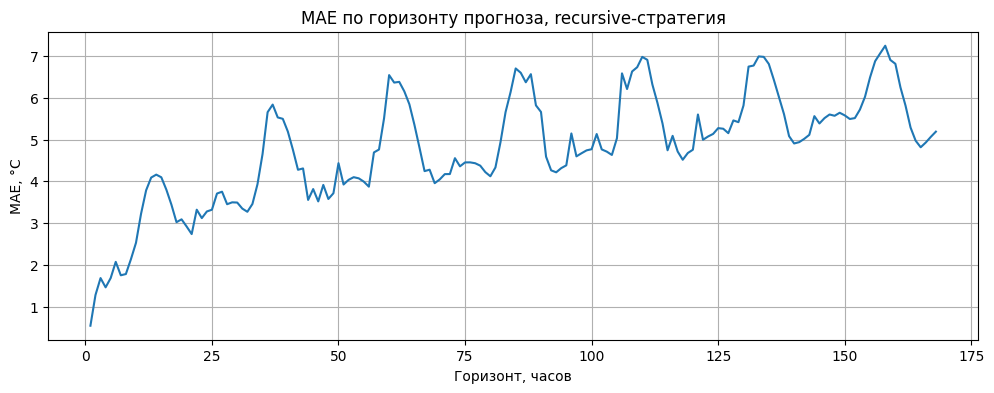

,horizon,MAE,WAPE_%,MAPE_%,directional_accuracy,directional_R2
158,159,6.911032,46.866220,137.353852,0.712963,-0.564883
159,160,6.817710,46.256699,144.048321,0.814815,-0.373352
160,161,6.254178,44.218428,148.759114,0.814815,-0.354039
161,162,5.817475,42.473372,133.337228,0.833333,-0.235200
162,163,5.290344,40.181242,117.271043,0.805556,-0.112763
163,164,4.975793,39.222369,108.073300,0.759259,-0.098396
164,165,4.817886,39.372836,97.362169,0.694444,-0.081068
165,166,4.931252,41.020966,91.893501,0.601852,-0.074629
166,167,5.067049,42.925932,90.303877,0.527778,-0.060830
167,168,5.192328,44.793631,91.731026,0.518519,-0.048833


In [39]:
horizon_test_metrics = []
for horizon, horizon_frame in recursive_test_forecast.groupby("horizon"):
    horizon_test_metrics.append(
        {
            "horizon": horizon,
            **regression_metrics(horizon_frame["y_true"], horizon_frame["y_pred"], horizon_frame["baseline"]),
        }
    )

horizon_test_metrics = pd.DataFrame(horizon_test_metrics)

ax = horizon_test_metrics.plot(x="horizon", y="MAE", figsize=(12, 4), legend=False)
ax.set_title("MAE по горизонту прогноза, recursive-стратегия")
ax.set_xlabel("Горизонт, часов")
ax.set_ylabel("MAE, °C")
plt.show()

horizon_test_metrics.tail(10)

### 6.1. Direct-прогноз на контрольных горизонтах

Direct-модели выше обучались для выбранных контрольных горизонтов. Проверим их на тех же тестовых якорных датах, но только в точках `1, 3, 6, ..., 168` часов.


In [40]:
def direct_forecast_for_anchors(models: dict[str, Pipeline], anchor_frame: pd.DataFrame, horizons: list[int]) -> pd.DataFrame:
    rows = []
    target_columns = [f"target_h{h}" for h in horizons]
    pred = predict_direct_models(models, anchor_frame, target_columns)

    for i, anchor in enumerate(anchor_frame.itertuples(index=False)):
        for j, horizon in enumerate(horizons):
            rows.append(
                {
                    "city": anchor.city,
                    "anchor_ds": anchor.ds,
                    "target_ds": anchor.ds + pd.Timedelta(hours=horizon),
                    "horizon": horizon,
                    "y_true": getattr(anchor, f"target_h{horizon}"),
                    "y_pred": pred[i, j],
                    "baseline": anchor.temperature_2m,
                }
            )
    return pd.DataFrame(rows)

# Собираем anchor_frame для тестовых дат и контрольных горизонтов.
direct_test_full = make_anchor_frame(feature_frame, DIRECT_TUNING_HORIZONS)
direct_test = direct_test_full.merge(
    test_anchors,
    left_on=["city", "ds"],
    right_on=["city", "anchor_ds"],
    how="inner",
)

direct_test_forecast = direct_forecast_for_anchors(best_direct_models, direct_test, DIRECT_TUNING_HORIZONS)

direct_test_metrics = regression_metrics(
    direct_test_forecast["y_true"],
    direct_test_forecast["y_pred"],
    direct_test_forecast["baseline"],
)

pd.DataFrame([{"strategy": "direct_control_horizons", "model": best_direct_name, **direct_test_metrics}])

,strategy,model,MAE,WAPE_%,MAPE_%,directional_accuracy,directional_R2
0,direct_control_horizons,hist_gradient_boosting,2.521308,22.222187,51.202423,0.71633,0.242508


In [41]:
strategy_test_comparison = pd.DataFrame(
    [
        {"strategy": "recursive_full_week", "model": best_recursive_name, **recursive_test_metrics},
        {"strategy": "direct_control_horizons", "model": best_direct_name, **direct_test_metrics},
    ]
)
strategy_test_comparison

,strategy,model,MAE,WAPE_%,MAPE_%,directional_accuracy,directional_R2
0,recursive_full_week,hist_gradient_boosting,4.784942,38.406107,99.538701,0.555445,-0.057296
1,direct_control_horizons,hist_gradient_boosting,2.521308,22.222187,51.202423,0.716330,0.242508


### 6.2. Визуальная проверка прогноза и анализ остатков

Графики ниже позволяют оценить не только средний уровень ошибки, но и её характер: возможное запаздывание модели, сглаживание экстремальных значений и увеличение ошибки на дальних горизонтах прогноза.


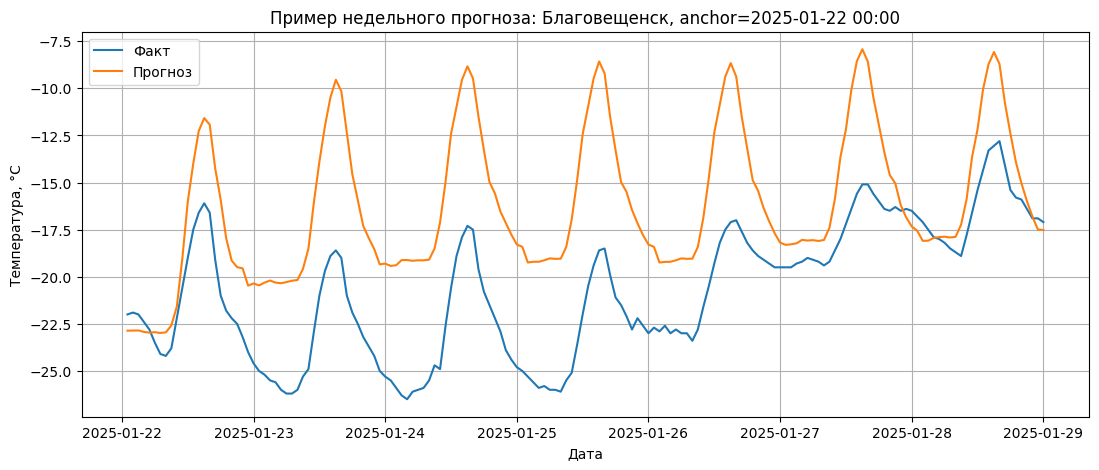

In [42]:
example_city = recursive_test_forecast["city"].iloc[0]
example_anchor = recursive_test_forecast.loc[recursive_test_forecast["city"] == example_city, "anchor_ds"].iloc[0]
example = recursive_test_forecast[
    (recursive_test_forecast["city"] == example_city)
    & (recursive_test_forecast["anchor_ds"] == example_anchor)
].copy()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(example["target_ds"], example["y_true"], label="Факт")
ax.plot(example["target_ds"], example["y_pred"], label="Прогноз")
ax.set_title(f"Пример недельного прогноза: {example_city}, anchor={example_anchor:%Y-%m-%d %H:%M}")
ax.set_xlabel("Дата")
ax.set_ylabel("Температура, °C")
ax.legend()
plt.show()

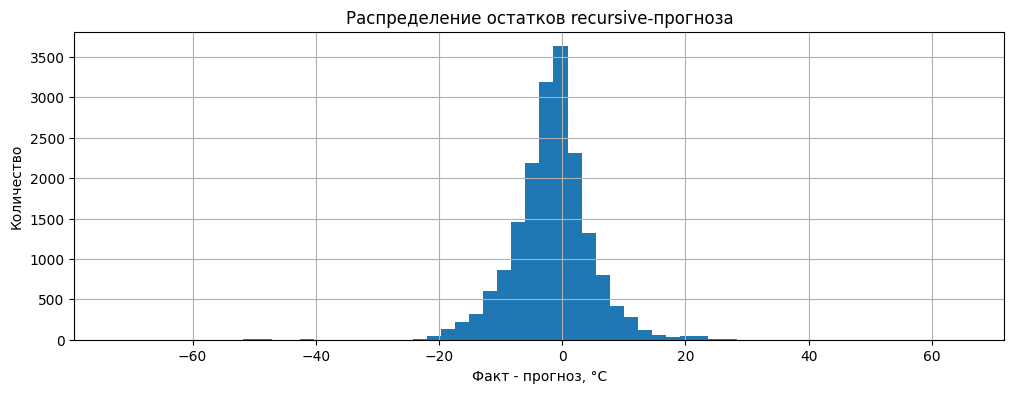

,mean,std,median,q05,q95
city,,,,,
Благовещенск,-3.737,6.416,-3.067,-16.011,6.438
Геленджик,-2.277,5.211,-1.528,-12.038,5.329
Москва,-0.619,7.097,-0.438,-10.924,10.763
Находка,1.138,8.402,0.352,-10.209,16.941
Санкт-Петербург,-2.037,5.890,-1.787,-12.725,7.583
Сочи,-2.288,3.990,-1.800,-9.902,3.548


In [43]:
recursive_test_forecast["residual"] = recursive_test_forecast["y_true"] - recursive_test_forecast["y_pred"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(recursive_test_forecast["residual"], bins=60)
ax.set_title("Распределение остатков recursive-прогноза")
ax.set_xlabel("Факт - прогноз, °C")
ax.set_ylabel("Количество")
plt.show()

residual_summary = recursive_test_forecast.groupby("city")["residual"].agg(
    mean="mean",
    std="std",
    median="median",
    q05=lambda x: x.quantile(0.05),
    q95=lambda x: x.quantile(0.95),
).round(3)
residual_summary

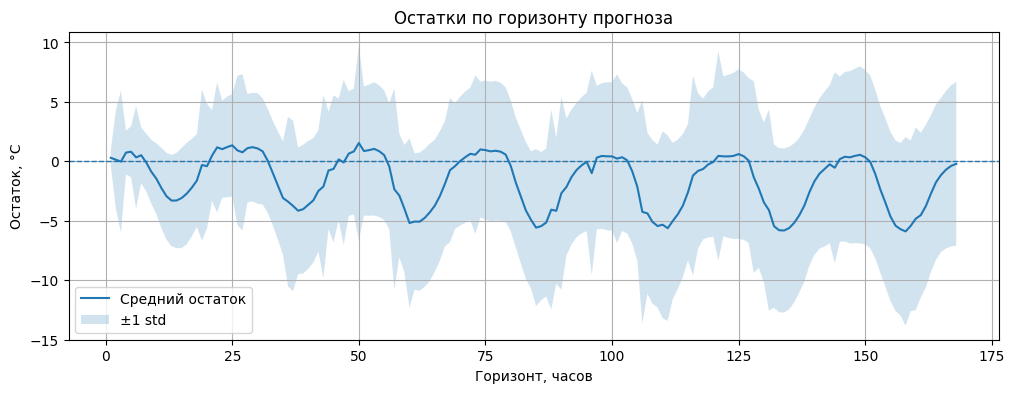

In [44]:
residual_by_horizon = recursive_test_forecast.groupby("horizon")["residual"].agg(
    mean="mean",
    std="std",
).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(residual_by_horizon["horizon"], residual_by_horizon["mean"], label="Средний остаток")
ax.fill_between(
    residual_by_horizon["horizon"],
    residual_by_horizon["mean"] - residual_by_horizon["std"],
    residual_by_horizon["mean"] + residual_by_horizon["std"],
    alpha=0.2,
    label="±1 std",
)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Остатки по горизонту прогноза")
ax.set_xlabel("Горизонт, часов")
ax.set_ylabel("Остаток, °C")
ax.legend()
plt.show()

### 6.3. Интерпретация результатов

Ключевые выводы по построенному пайплайну:

1. Исходный Excel-файл действительно нуждается в восстановлении: в нём есть скрытые листы, смещённый блок данных, нарушенная кодировка, строковые обозначения пропусков, ошибки в названиях городов и выбросы.
2. После этапа очистки получен согласованный многомерный почасовой ряд для 6 городов.
3. Анализ выявляет выраженную годовую и суточную сезонность, поэтому календарные признаки и лаги на 24/168 часов являются обоснованными.
4. Recursive-стратегия удобна для построения полного недельного прогноза, однако ошибка обычно увеличивается с ростом горизонта.
5. Direct-стратегия даёт больший контроль над отдельными горизонтами, но требует обучения большего числа моделей и дополнительных вычислений.
6. Для дальнейшего повышения качества можно увеличить число trials в Optuna, обучить direct-модели для всех 168 горизонтов и добавить внешние погодные признаки.


In [45]:
# Финальная компактная таблица для отчёта.
final_report = {
    "parse_diagnostics": parse_diagnostics,
    "bounds_report": bounds_report,
    "cleaning_summary": cleaning_summary.round(2),
    "strategy_test_comparison": strategy_test_comparison.round(4),
    "city_test_metrics": city_test_metrics.round(4),
}

for name, table in final_report.items():
    print(f"\n{name}")
    display(table)


parse_diagnostics


,sheet_name_raw,sheet_name,sheet_state,table_start_columns,rows_scanned,rows_extracted
0,Лист1,Лист1,visible,[1],125125,125124
1,Лист1,Лист1,visible,[],0,0
2,МАИ,МАИ,visible,[],1000,0
3,это,это,visible,[],1000,0
4,я,я,visible,[],1000,0
5,!,!,visible,[],1000,0
6,Лист2_строковые_NaN_выбросы,Лист2_строковые_NaN_выбросы,hidden,"[1, 16, 12]",125170,122828
7,Лист3_смешанные_типы,Лист3_смешанные_типы,hidden,[1],122737,122736



bounds_report


,column,values_outside_bounds,lower_bound,upper_bound
0,temperature_2m,427,-60,60
1,relative_humidity_2m,0,0,100
2,precipitation,613,0,80
3,rain,0,0,80
4,snowfall,0,0,80
5,weathercode,0,0,99
6,wind_speed_10m,613,0,70
7,surface_pressure,232,850,1100



cleaning_summary


,start,end,observations,temp_min,temp_mean,temp_max
city,,,,,,
Благовещенск,2019-01-01,2025-12-31 23:00:00,61368,-41.90,2.21,35.00
Геленджик,2019-01-01,2025-12-31 23:00:00,61368,-10.00,14.36,37.80
Москва,2019-01-01,2025-12-31 23:00:00,61368,-49.98,6.68,59.95
Находка,2019-01-01,2025-12-31 22:00:00,61367,-49.99,6.83,59.97
Санкт-Петербург,2019-01-01,2025-12-31 23:00:00,61368,-28.80,6.79,35.70
Сочи,2019-01-01,2025-12-31 23:00:00,61368,-11.20,15.04,35.30



strategy_test_comparison


,strategy,model,MAE,WAPE_%,MAPE_%,directional_accuracy,directional_R2
0,recursive_full_week,hist_gradient_boosting,4.7849,38.4061,99.5387,0.5554,-0.0573
1,direct_control_horizons,hist_gradient_boosting,2.5213,22.2222,51.2024,0.7163,0.2425



city_test_metrics


,city,MAE,WAPE_%,MAPE_%,directional_accuracy,directional_R2
5,Сочи,3.3782,23.5433,62.7739,0.6104,-0.2602
1,Геленджик,4.2038,29.4233,77.1352,0.5926,-0.1600
4,Санкт-Петербург,4.7159,48.8089,137.5864,0.5258,-0.1375
2,Москва,5.0661,50.4348,116.4256,0.5218,-0.0153
3,Находка,5.6569,49.0527,103.0761,0.5314,-0.0084
0,Благовещенск,5.6887,38.2370,100.2351,0.5506,-0.3300


## 8. Вывод

1. **Доступ к Excel-файлу.**
   Все листы книги были просмотрены через `openpyxl`, включая скрытые. Затем данные были считаны с помощью `pandas.read_excel`, после чего выделены три листа, содержащие полезные погодные временные ряды.

2. **Очистка и унификация данных.**
   Был восстановлен смещённый блок данных, исправлены проблемы с кодировкой и названиями городов, обработаны строковые обозначения пропусков, дубликаты, физически невозможные значения, локальные выбросы и одиночные скачки температуры. Итоговый датафрейм `weather_clean` приведён к единому почасовому индексу `city` + `ds`.

3. **Анализ временного ряда.**
   Для температуры были построены визуализации, ACF/PACF, тесты стационарности, STL-декомпозиция, FFT-спектр, STFT-спектрограмма и вейвлет-скалограмма. Анализ подтвердил наличие сильной годовой сезонности, заметного суточного цикла и зависимости температуры от предыдущих значений.

4. **Признаки для прогнозирования.**
   Для модели подготовлены календарные признаки, one-hot кодирование города, текущие погодные параметры, лаги, разности, rolling-статистики и компактные признаки `tsfresh`. Длина исторического окна выбрана равной `14` дням, а горизонт прогноза — `7` дням, то есть `+1 ... +168` часов.

5. **Модели и стратегии прогноза.**
   Были обучены дерево решений, случайный лес и бустинг. Гиперпараметры подбирались через `Optuna` с expanding time-series cross-validation. Также были сопоставлены две стратегии: recursive-прогноз одной моделью на `+1` час и direct-прогноз отдельными моделями для горизонтов `+1 ... +168`.

6. **Оценка качества.**
   Финальная модель выбрана по результатам валидации и затем проверена на тестовом отрезке. Рассчитаны требуемые метрики: `WAPE`, `MAE`, `MAPE`, `directional accuracy`, `directional R2`. Дополнительно использованы `MAE@h`, `MAE_macro`, `MAE_pooled`, чтобы сравнить качество на разных горизонтах прогноза.

7. **Анализ ошибок.**
   Построены графики фактических и прогнозных значений, распределение остатков, ошибки по городам и месяцам, а также ACF остатков. Модель хорошо передаёт общий сезонный ход температуры, однако в остатках сохраняется краткосрочная автокорреляция: часть быстрых погодных изменений сглаживается.

8. **Внешняя проверка.**
   Дополнительно проведена проверка на данных Open-Meteo по Москве за апрель 2026 года. Этот этап показывает, как готовый пайплайн можно использовать для новых данных, полученных через API.

Итог: собран воспроизводимый пайплайн от восстановления проблемного Excel-файла до многошагового прогноза температуры, сравнения стратегий и анализа ошибок модели.
